## Exploratoty Data Analysis

In [1]:
# pandas -> working with tables/dataframes
import pandas as pd

# numpy -> numerical operations
import numpy as np

# matplotlib -> plotting charts
import matplotlib.pyplot as plt

# seaborn -> easier statistical visualizations
import seaborn as sns

# pathlib -> handling folders and file paths
from pathlib import Path


# Make charts slightly larger and easier to read
plt.rcParams["figure.figsize"] = (10, 6)

# Improve display of pandas tables
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# LOAD CLEANED DATA
# ============================================================

file_path = "../data/processed/cleaned_data.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["VisitDate"]
)

print("Dataset loaded successfully.")

print("\nDataset shape:")
print(df.shape)

display(df.head())

Dataset loaded successfully.

Dataset shape:
(52930, 22)


,TransactionId,UserId,VisitDate,VisitYear,VisitMonth,VisitModeId,VisitMode,AttractionId,Attraction,AttractionAddress,AttractionCityId,AttractionTypeId,AttractionType,Rating,CityId,CityName,CountryId,Country,RegionId,Region,ContinentId,Continent
0,3,70456,2022-10-01,2022,10,2,Couples,640,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",1,63,Nature & Wildlife Areas,5,4341.0,Guildford,163,United Kingdom,21,Western Europe,5,Europe
1,8,7567,2022-10-01,2022,10,4,Friends,640,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",1,63,Nature & Wildlife Areas,5,464.0,Ontario,48,Canada,8,Northern America,2,America
2,9,79069,2022-10-01,2022,10,3,Family,640,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",1,63,Nature & Wildlife Areas,5,774.0,Brazil,54,Brazil,9,South America,2,America
3,10,31019,2022-10-01,2022,10,3,Family,640,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",1,63,Nature & Wildlife Areas,3,583.0,Zurich,135,Switzerland,17,Central Europe,5,Europe
4,15,43611,2022-10-01,2022,10,2,Couples,640,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",1,63,Nature & Wildlife Areas,3,1396.0,Manchester,163,United Kingdom,21,Western Europe,5,Europe


In [3]:
# ============================================================
# QUICK DATA CHECK
# ============================================================

print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape:
(52930, 22)

Columns:
['TransactionId', 'UserId', 'VisitDate', 'VisitYear', 'VisitMonth', 'VisitModeId', 'VisitMode', 'AttractionId', 'Attraction', 'AttractionAddress', 'AttractionCityId', 'AttractionTypeId', 'AttractionType', 'Rating', 'CityId', 'CityName', 'CountryId', 'Country', 'RegionId', 'Region', 'ContinentId', 'Continent']

Missing values:
TransactionId         0
UserId                0
VisitDate             0
VisitYear             0
VisitMonth            0
VisitModeId           0
VisitMode             0
AttractionId          0
Attraction            0
AttractionAddress     0
AttractionCityId      0
AttractionTypeId      0
AttractionType        0
Rating                0
CityId                8
CityName              8
CountryId             0
Country               0
RegionId              0
Region               32
ContinentId           0
Continent             0
dtype: int64

Duplicate rows:
0

Data types:
TransactionId                 int64
UserId                    

In [4]:
# ============================================================
# CREATE FOLDER FOR EDA CHARTS
# ============================================================

charts_path = Path("../charts")

# Create folder if it doesn't already exist
charts_path.mkdir(exist_ok=True)

print("Charts will be saved in:")
print(charts_path.resolve())

Charts will be saved in:
/home/kusuma-rani-sutar/tourism-analytics/charts


EDA PART 1 — User geographic distribution

Your requirement says:

User distribution across continent/country/region/city.

There is one important detail.

Our dataset is at transaction level, so if we simply count rows, users who visited many times would appear multiple times.

For genuine user distribution, use each UserId only once.

#### Create user-level geographic dataset

In [6]:
# ============================================================
# CREATE UNIQUE USER DATASET
# ============================================================

user_geo = (
    df[
        [
            "UserId",
            "Continent",
            "Region",
            "Country",
            "CityName"
        ]
    ]
    .drop_duplicates(subset="UserId")
)

print("Number of unique users:")
print(user_geo["UserId"].nunique())

display(user_geo.head())

Number of unique users:
33530


,UserId,Continent,Region,Country,CityName
0,70456,Europe,Western Europe,United Kingdom,Guildford
1,7567,America,Northern America,Canada,Ontario
2,79069,America,South America,Brazil,Brazil
3,31019,Europe,Central Europe,Switzerland,Zurich
4,43611,Europe,Western Europe,United Kingdom,Manchester


### CHART 1 — Users by continent

Continent
Australia & Oceania    9837
Asia                   9822
Europe                 8260
America                5018
Africa                  593
Name: count, dtype: int64


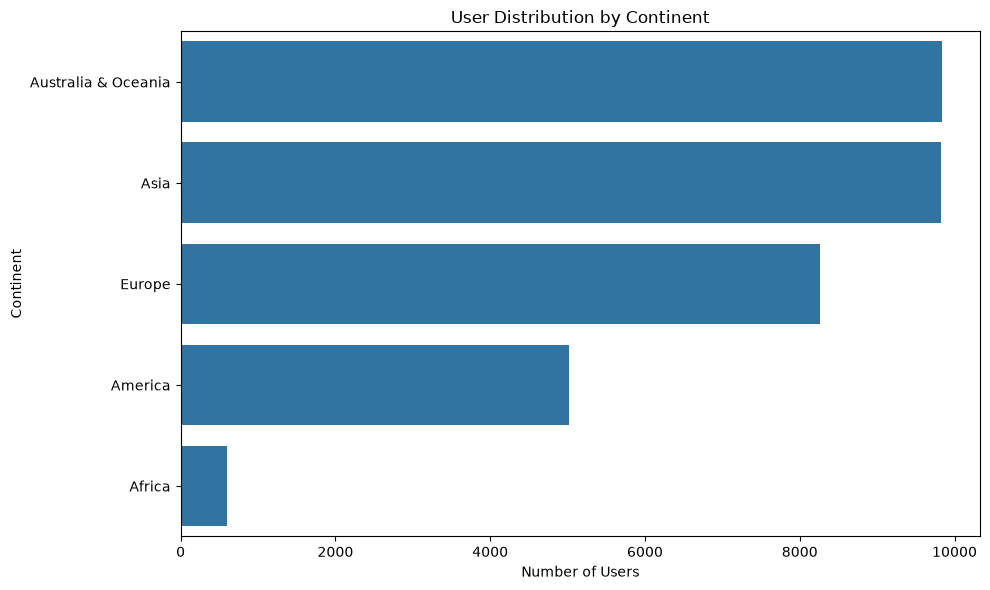

In [7]:
# ============================================================
# CHART 1 - USER DISTRIBUTION BY CONTINENT
# ============================================================

continent_counts = (
    user_geo["Continent"]
    .value_counts()
    .sort_values(ascending=False)
)

print(continent_counts)


plt.figure(figsize=(10, 6))

sns.barplot(
    x=continent_counts.values,
    y=continent_counts.index
)

plt.title("User Distribution by Continent")
plt.xlabel("Number of Users")
plt.ylabel("Continent")

plt.tight_layout()

# Save chart
plt.savefig(
    charts_path / "01_users_by_continent.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CHART 2 — Top 15 countries by users

Country
Australia               8848
United Kingdom          4062
United States           3799
Indonesia               2889
Singapore               1815
India                   1627
New Zealand              959
Malaysia                 919
Canada                   916
Netherlands              570
China                    415
South Africa             395
Poland                   361
United Arab Emirates     358
Germany                  354
Name: count, dtype: int64


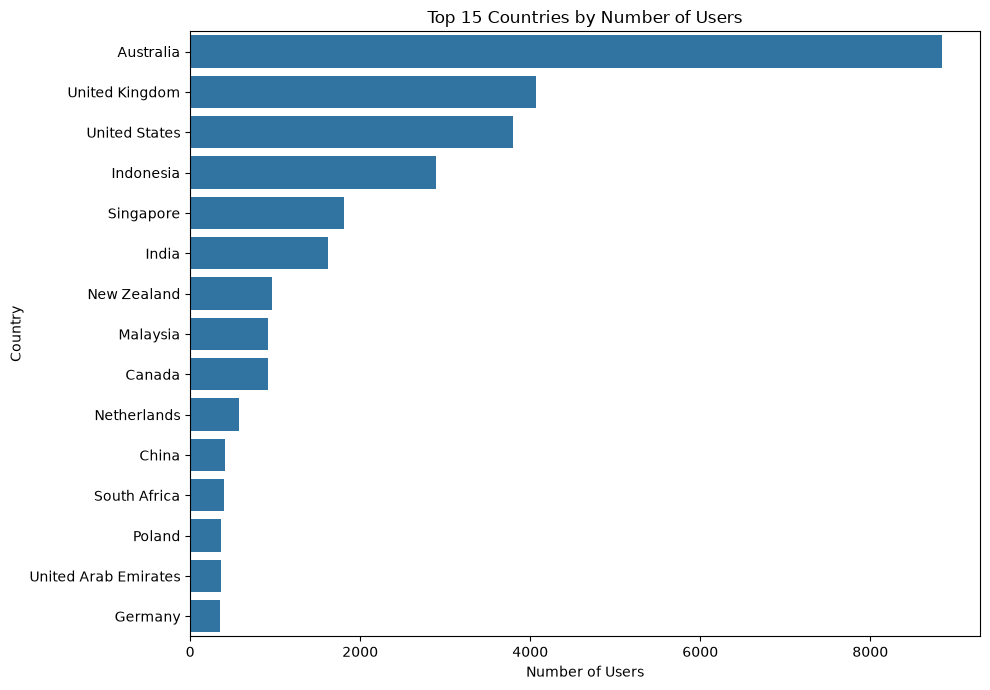

In [8]:
# ============================================================
# CHART 2 - TOP 15 COUNTRIES BY USERS
# ============================================================

country_counts = (
    user_geo["Country"]
    .value_counts()
    .head(15)
)

print(country_counts)


plt.figure(figsize=(10, 7))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 15 Countries by Number of Users")
plt.xlabel("Number of Users")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    charts_path / "02_top_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CHART 3 — Top regions

Region
Australia           8848
South East Asia     6387
Western Europe      5275
Northern America    4788
South Asia          1858
Central Europe      1421
Oceania              989
Middle East          835
East Asia            718
Southern Europe      637
Northern Europe      587
Southern Africa      410
Eastern Europe       334
South America        163
North Africa         118
Name: count, dtype: int64


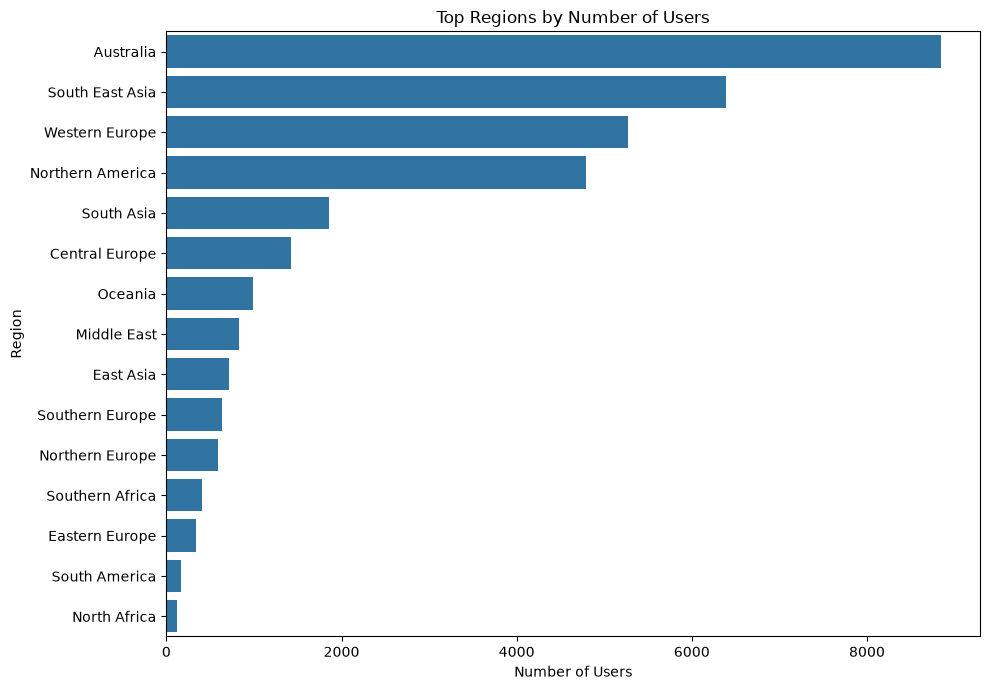

In [9]:
# ============================================================
# CHART 3 - USER DISTRIBUTION BY REGION
# ============================================================

region_counts = (
    user_geo["Region"]
    .value_counts()
    .head(15)
)

print(region_counts)


plt.figure(figsize=(10, 7))

sns.barplot(
    x=region_counts.values,
    y=region_counts.index
)

plt.title("Top Regions by Number of Users")
plt.xlabel("Number of Users")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    charts_path / "03_top_regions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CHART 4 — Top cities

CityName
Singapore       1784
Melbourne       1502
Perth           1232
London          1002
Sydney           978
Greenwich        826
Jakarta          749
Adelaide         623
Brisbane         554
Kuala Lumpur     422
Bali             386
Mumbai           353
Pontypridd       321
Warsaw           310
Dubai            270
Name: count, dtype: int64


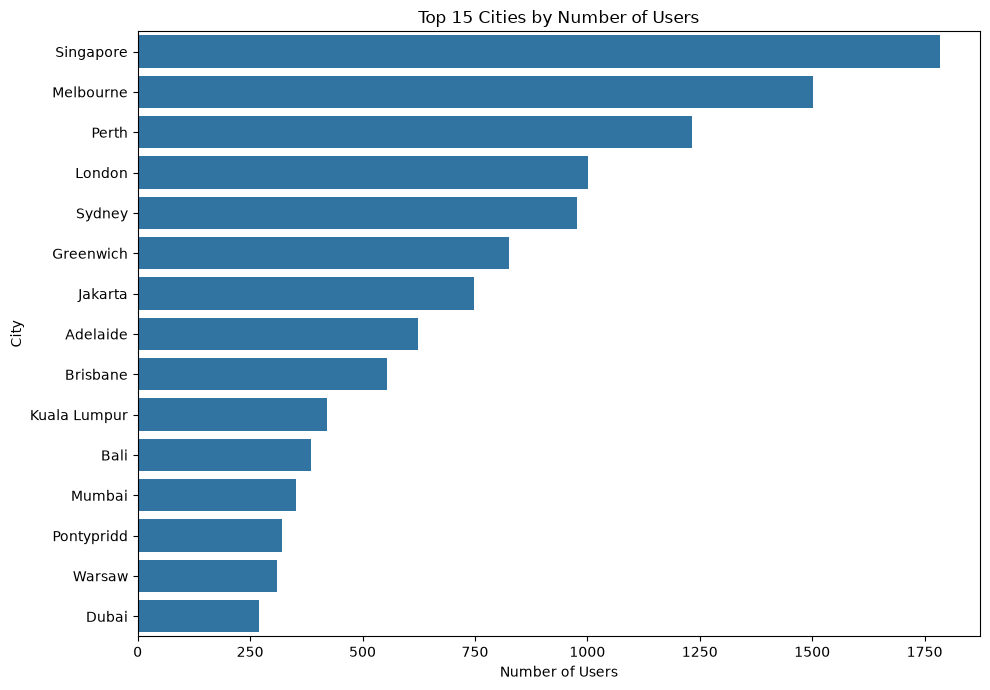

In [10]:
# ============================================================
# CHART 4 - TOP 15 CITIES BY USERS
# ============================================================

city_counts = (
    user_geo["CityName"]
    .value_counts()
    .head(15)
)

print(city_counts)


plt.figure(figsize=(10, 7))

sns.barplot(
    x=city_counts.values,
    y=city_counts.index
)

plt.title("Top 15 Cities by Number of Users")
plt.xlabel("Number of Users")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    charts_path / "04_top_cities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

EDA PART 2 — Attraction popularity

Now we want:

Attraction type popularity — count + average rating.

We'll calculate both together.

#### STEP 7 — Attraction type summary

In [11]:
# ============================================================
# ATTRACTION TYPE SUMMARY
# ============================================================

attraction_type_summary = (
    df
    .groupby("AttractionType")
    .agg(
        VisitCount=("TransactionId", "count"),
        AverageRating=("Rating", "mean")
    )
    .reset_index()
)

# Round average ratings for easier reading
attraction_type_summary["AverageRating"] = (
    attraction_type_summary["AverageRating"].round(2)
)

# Sort by number of visits
attraction_type_summary = (
    attraction_type_summary
    .sort_values(
        "VisitCount",
        ascending=False
    )
)

display(attraction_type_summary)

,AttractionType,VisitCount,AverageRating
8,Nature & Wildlife Areas,13251,4.27
2,Beaches,10917,3.85
11,Religious Sites,6711,4.21
15,Water Parks,6429,4.65
10,Points of Interest & Landmarks,6252,4.13
14,Volcanos,2318,4.10
16,Waterfalls,2245,3.90
4,Flea & Street Markets,1324,3.87
6,History Museums,978,4.26
5,Historic Sites,798,3.54


### CHART 5 — Attraction type popularity

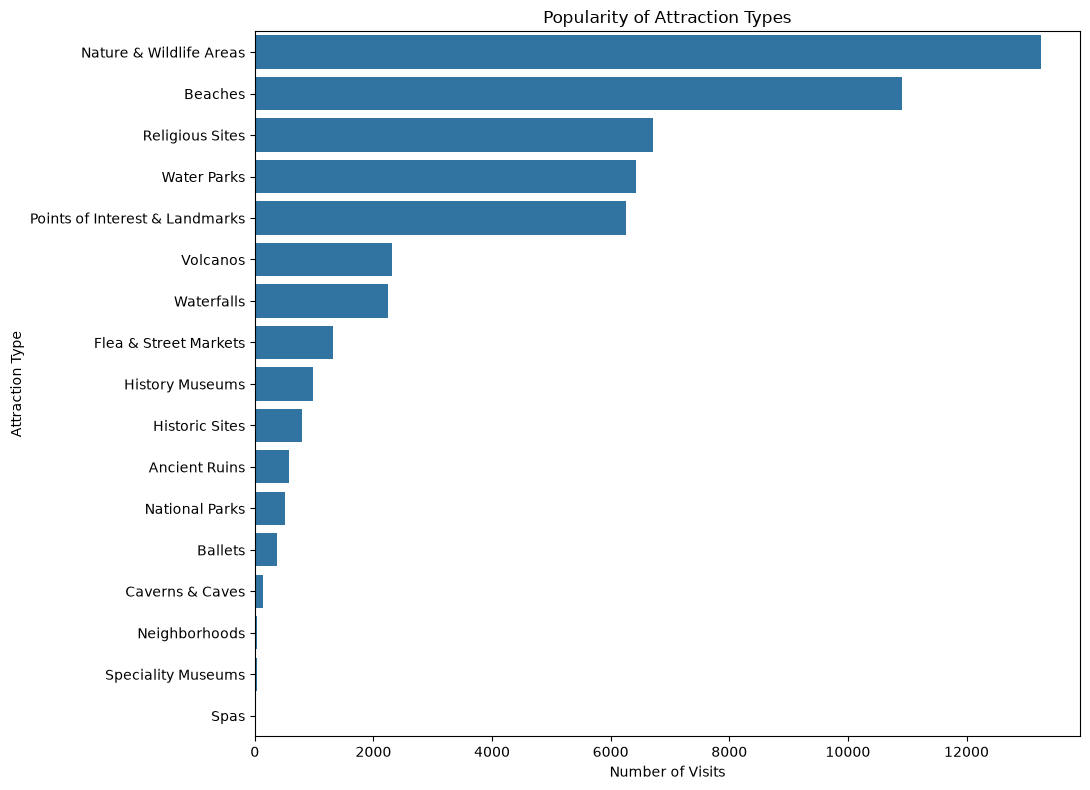

In [12]:
# ============================================================
# CHART 5 - ATTRACTION TYPE POPULARITY
# ============================================================

popularity = (
    attraction_type_summary
    .sort_values(
        "VisitCount",
        ascending=False
    )
)


plt.figure(figsize=(11, 8))

sns.barplot(
    data=popularity,
    x="VisitCount",
    y="AttractionType"
)

plt.title("Popularity of Attraction Types")
plt.xlabel("Number of Visits")
plt.ylabel("Attraction Type")

plt.tight_layout()

plt.savefig(
    charts_path / "05_attraction_type_popularity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### CHART 6 — Average rating by attraction type

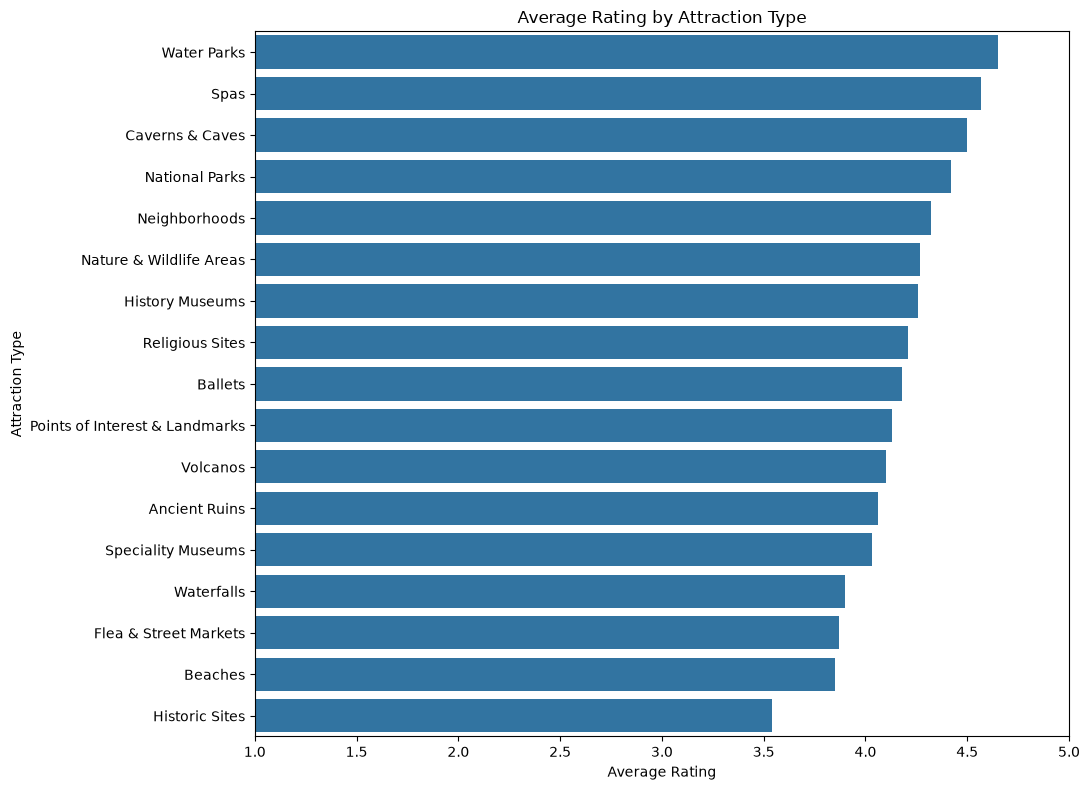

In [13]:
# ============================================================
# CHART 6 - AVERAGE RATING BY ATTRACTION TYPE
# ============================================================

rating_by_type = (
    attraction_type_summary
    .sort_values(
        "AverageRating",
        ascending=False
    )
)


plt.figure(figsize=(11, 8))

sns.barplot(
    data=rating_by_type,
    x="AverageRating",
    y="AttractionType"
)

plt.title("Average Rating by Attraction Type")
plt.xlabel("Average Rating")
plt.ylabel("Attraction Type")

# Since ratings are 1 to 5
plt.xlim(1, 5)

plt.tight_layout()

plt.savefig(
    charts_path / "06_attraction_type_avg_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### EDA PART 3 — Rating distribution

CHART 7 — Overall rating distribution

Rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64


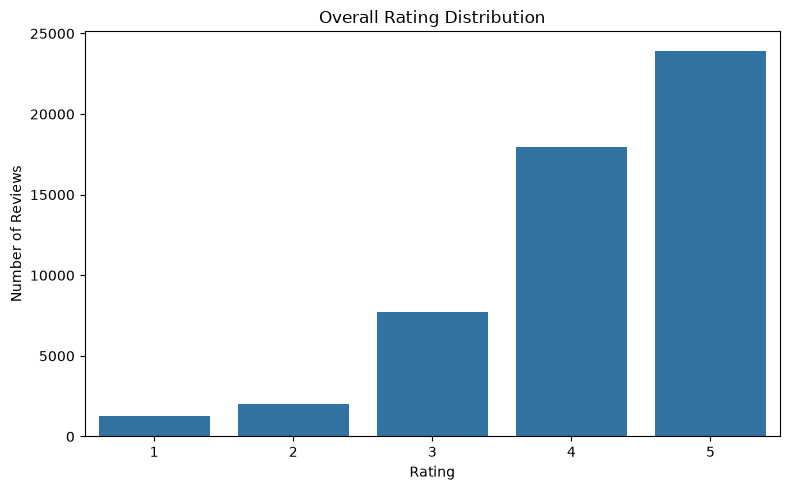

In [15]:
# ============================================================
# CHART 7 - OVERALL RATING DISTRIBUTION
# ============================================================

rating_counts = (
    df["Rating"]
    .value_counts()
    .sort_index()
)

print(rating_counts)


plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Rating"
)

plt.title("Overall Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.tight_layout()

plt.savefig(
    charts_path / "07_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### STEP 8 — Average rating by attraction

In [16]:
# ============================================================
# ATTRACTION LEVEL RATING SUMMARY
# ============================================================

attraction_rating = (
    df
    .groupby("Attraction")
    .agg(
        AverageRating=("Rating", "mean"),
        VisitCount=("TransactionId", "count")
    )
    .reset_index()
)

attraction_rating["AverageRating"] = (
    attraction_rating["AverageRating"].round(2)
)

display(
    attraction_rating
    .sort_values(
        "AverageRating",
        ascending=False
    )
    .head(10)
)

,Attraction,AverageRating,VisitCount
12,Mount Semeru Volcano,4.70,83
28,Waterbom Bali,4.65,6429
1,Bromo Tengger Semeru National Park,4.61,381
7,Khayangan Reflexology & Massage,4.57,28
5,Jomblang Cave,4.50,135
4,Jodipan Colorful Village,4.32,44
14,Nusa Dua Beach,4.28,2104
17,Sacred Monkey Forest Sanctuary,4.27,13198
25,Ullen Sentalu Museum,4.26,978
26,Uluwatu Temple,4.22,3359


### CHART 8 — Top attractions by average rating

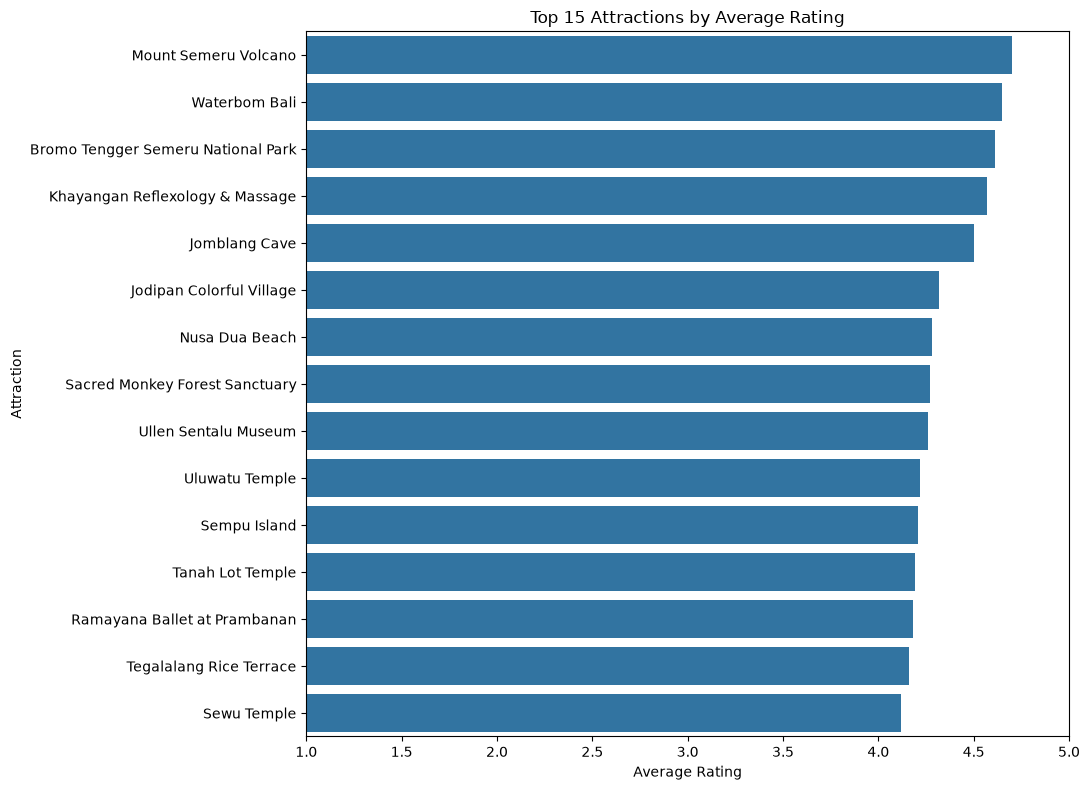

In [17]:
# ============================================================
# CHART 8 - TOP 15 ATTRACTIONS BY AVERAGE RATING
# ============================================================

top_attractions = (
    attraction_rating
    .sort_values(
        "AverageRating",
        ascending=False
    )
    .head(15)
)


plt.figure(figsize=(11, 8))

sns.barplot(
    data=top_attractions,
    x="AverageRating",
    y="Attraction"
)

plt.title("Top 15 Attractions by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Attraction")

plt.xlim(1, 5)

plt.tight_layout()

plt.savefig(
    charts_path / "08_top_attractions_ratings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# ============================================================
# AVERAGE RATING BY REGION
# ============================================================

region_rating = (
    df
    .groupby("Region")
    .agg(
        AverageRating=("Rating", "mean"),
        NumberOfVisits=("TransactionId", "count")
    )
    .reset_index()
)

region_rating["AverageRating"] = (
    region_rating["AverageRating"].round(2)
)

region_rating = (
    region_rating
    .sort_values(
        "AverageRating",
        ascending=False
    )
)

display(region_rating)

,Region,AverageRating,NumberOfVisits
4,Central Asia,4.50,16
10,North Africa,4.29,182
9,Middle East,4.24,1266
0,Australia,4.22,13322
15,South Asia,4.22,2874
1,Caribbean,4.20,54
11,Northern America,4.17,7847
13,Oceania,4.15,1530
3,Central America,4.13,46
16,South East Asia,4.13,10392


### EDA PART 4 — VisitMode vs demographics


### STEP 9 — Create VisitMode vs Region crosstab

In [20]:
# ============================================================
# VISIT MODE VS REGION
# ============================================================

visitmode_region = pd.crosstab(
    df["Region"],
    df["VisitMode"],
    normalize="index"
) * 100

# Round percentages
visitmode_region = visitmode_region.round(1)

display(visitmode_region)

VisitMode,Business,Couples,Family,Friends,Solo
Region,,,,,
Australia,0.4,36.9,39.7,17.5,5.5
Caribbean,0.0,44.4,11.1,20.4,24.1
Central Africa,0.0,0.0,28.6,0.0,71.4
Central America,0.0,37.0,26.1,13.0,23.9
Central Asia,0.0,31.2,43.8,18.8,6.2
Central Europe,0.9,47.3,19.7,24.1,8.1
East Africa,0.0,33.3,25.8,31.8,9.1
East Asia,0.6,42.0,27.4,18.6,11.3
Eastern Europe,1.7,32.8,23.6,26.3,15.6


### CHART 9 — VisitMode vs Region heatmap

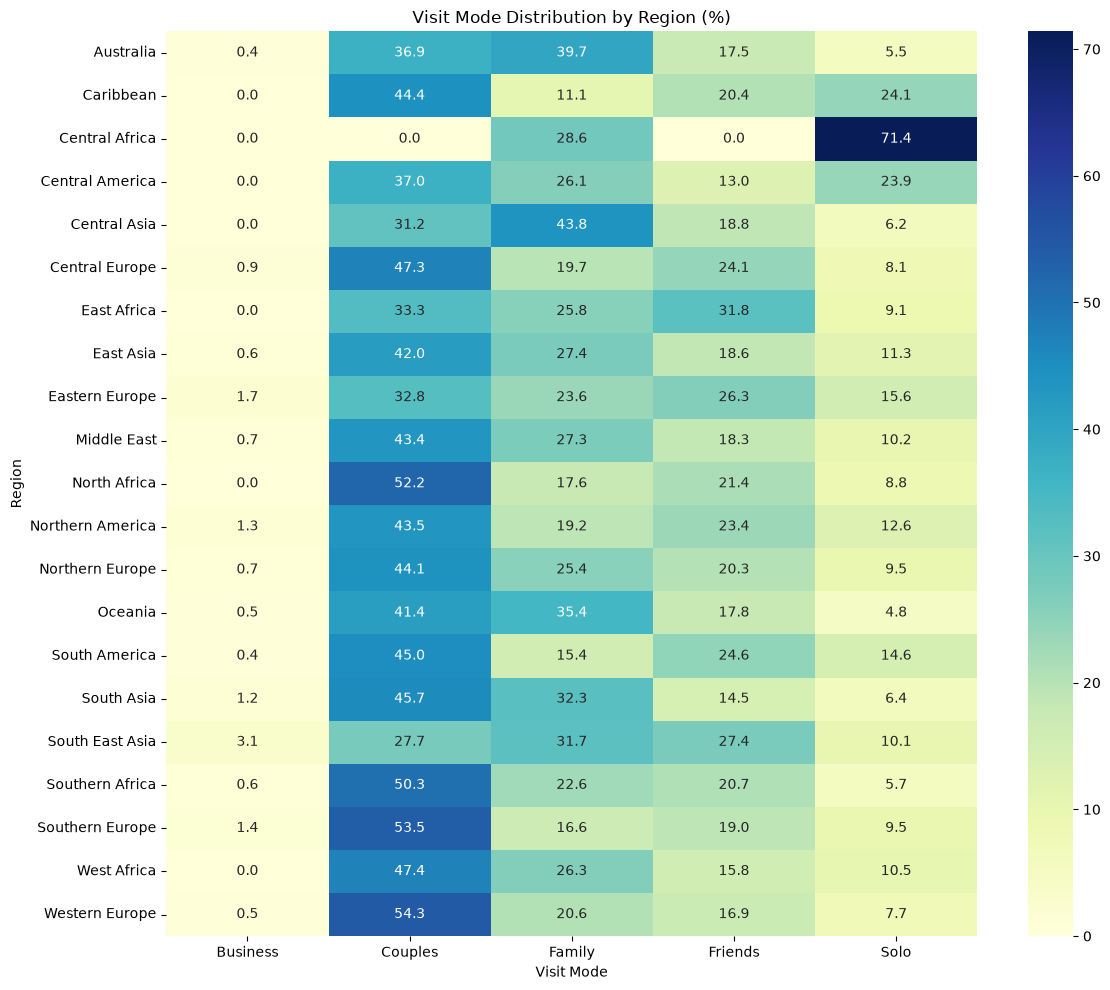

In [21]:
# ============================================================
# CHART 9 - VISIT MODE VS REGION
# ============================================================

plt.figure(figsize=(12, 10))

sns.heatmap(
    visitmode_region,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Visit Mode Distribution by Region (%)")
plt.xlabel("Visit Mode")
plt.ylabel("Region")

plt.tight_layout()

plt.savefig(
    charts_path / "09_visitmode_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

EDA PART 5 — Correlation heatmap

A correlation heatmap should use numeric analytical variables, not meaningless arbitrary identifiers wherever possible.

For example:

TransactionId
UserId
CountryId

are numbers, but calculating correlation between IDs is usually meaningless.

So we'll exclude most database IDs.

### STEP 10 — Select useful numeric features

In [22]:
# ============================================================
# SELECT NUMERIC FEATURES FOR CORRELATION
# ============================================================

numeric_columns = [
    "VisitYear",
    "VisitMonth",
    "Rating",
    "VisitModeId"
]

# Only keep columns that actually exist
numeric_columns = [
    column
    for column in numeric_columns
    if column in df.columns
]

correlation_data = df[numeric_columns]

display(correlation_data.head())

,VisitYear,VisitMonth,Rating,VisitModeId
0,2022,10,5,2
1,2022,10,5,4
2,2022,10,5,3
3,2022,10,3,3
4,2022,10,3,2


### CHART 10 — Correlation heatmap

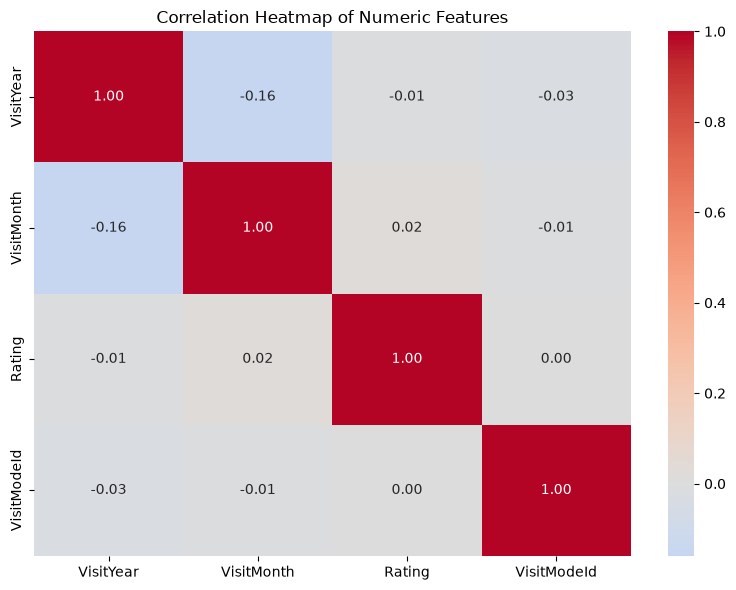

In [23]:
# ============================================================
# CHART 10 - CORRELATION HEATMAP
# ============================================================

correlation_matrix = (
    correlation_data
    .corr()
)


plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numeric Features")

plt.tight_layout()

plt.savefig(
    charts_path / "10_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### STEP 11 — Generate tables for your business insights

In [24]:
# ============================================================
# BUSINESS INSIGHT SUPPORT TABLES
# ============================================================

print("=" * 70)
print("1. TOP CONTINENTS")
print("=" * 70)

display(
    user_geo["Continent"]
    .value_counts()
    .head(10)
)


print("\n" + "=" * 70)
print("2. TOP COUNTRIES")
print("=" * 70)

display(
    user_geo["Country"]
    .value_counts()
    .head(10)
)


print("\n" + "=" * 70)
print("3. MOST POPULAR ATTRACTION TYPES")
print("=" * 70)

display(
    attraction_type_summary
    .head(10)
)


print("\n" + "=" * 70)
print("4. HIGHEST RATED ATTRACTION TYPES")
print("=" * 70)

display(
    attraction_type_summary
    .sort_values(
        "AverageRating",
        ascending=False
    )
    .head(10)
)


print("\n" + "=" * 70)
print("5. MOST COMMON VISIT MODES")
print("=" * 70)

display(
    df["VisitMode"]
    .value_counts()
)


print("\n" + "=" * 70)
print("6. HIGHEST RATED ATTRACTIONS")
print("=" * 70)

display(
    attraction_rating
    .sort_values(
        "AverageRating",
        ascending=False
    )
    .head(10)
)


print("\n" + "=" * 70)
print("7. REGION RATING SUMMARY")
print("=" * 70)

display(
    region_rating
    .head(10)
)


print("\n" + "=" * 70)
print("8. VISIT MODE BY REGION (%)")
print("=" * 70)

display(visitmode_region)

1. TOP CONTINENTS


Continent
Australia & Oceania    9837
Asia                   9822
Europe                 8260
America                5018
Africa                  593
Name: count, dtype: int64


2. TOP COUNTRIES


Country
Australia         8848
United Kingdom    4062
United States     3799
Indonesia         2889
Singapore         1815
India             1627
New Zealand        959
Malaysia           919
Canada             916
Netherlands        570
Name: count, dtype: int64


3. MOST POPULAR ATTRACTION TYPES


...

,Attraction,AverageRating,VisitCount
12,Mount Semeru Volcano,4.70,83
28,Waterbom Bali,4.65,6429
1,Bromo Tengger Semeru National Park,4.61,381
7,Khayangan Reflexology & Massage,4.57,28
5,Jomblang Cave,4.50,135
4,Jodipan Colorful Village,4.32,44
14,Nusa Dua Beach,4.28,2104
17,Sacred Monkey Forest Sanctuary,4.27,13198
25,Ullen Sentalu Museum,4.26,978
26,Uluwatu Temple,4.22,3359



7. REGION RATING SUMMARY


,Region,AverageRating,NumberOfVisits
4,Central Asia,4.50,16
10,North Africa,4.29,182
9,Middle East,4.24,1266
0,Australia,4.22,13322
15,South Asia,4.22,2874
1,Caribbean,4.20,54
11,Northern America,4.17,7847
13,Oceania,4.15,1530
3,Central America,4.13,46
16,South East Asia,4.13,10392



8. VISIT MODE BY REGION (%)


VisitMode,Business,Couples,Family,Friends,Solo
Region,,,,,
Australia,0.4,36.9,39.7,17.5,5.5
Caribbean,0.0,44.4,11.1,20.4,24.1
Central Africa,0.0,0.0,28.6,0.0,71.4
Central America,0.0,37.0,26.1,13.0,23.9
Central Asia,0.0,31.2,43.8,18.8,6.2
Central Europe,0.9,47.3,19.7,24.1,8.1
East Africa,0.0,33.3,25.8,31.8,9.1
East Asia,0.6,42.0,27.4,18.6,11.3
Eastern Europe,1.7,32.8,23.6,26.3,15.6


In [26]:
# ============================================================
# DAY 2 FINAL CHECK
# ============================================================

print("=" * 70)
print("DAY 2 - EDA COMPLETION CHECK")
print("=" * 70)

print("\nDataset rows:", len(df))

print(
    "Unique users:",
    df["UserId"].nunique()
)

print(
    "Unique attractions:",
    df["AttractionId"].nunique()
)

print(
    "Unique attraction types:",
    df["AttractionType"].nunique()
)

print(
    "Unique countries:",
    df["Country"].nunique()
)

print(
    "Unique regions:",
    df["Region"].nunique()
)

print(
    "Unique visit modes:",
    df["VisitMode"].nunique()
)

print(
    "\nSaved charts:",
    len(list(charts_path.glob("*.png")))
)



print("\n" + "=" * 70)
print("DAY 2 EDA PIPELINE COMPLETE")
print("=" * 70)

DAY 2 - EDA COMPLETION CHECK

Dataset rows: 52930
Unique users: 33530
Unique attractions: 30
Unique attraction types: 17
Unique countries: 153
Unique regions: 21
Unique visit modes: 5

Saved charts: 10

DAY 2 EDA PIPELINE COMPLETE
